In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
import anndata as ad
import igraph
import random
import squidpy as sq
import pickle


# Load

In [2]:
PATH = '/nfs/team298/ls34/adult_skin/final_adatas/adata_combined_new.h5ad.final.filtered.nohealthy'
adata=sc.read_h5ad(PATH)
adata=adata[adata.obs["tech"]=="xenium"].copy()


def remove_markers(LIST):
    try: 
        LIST = {key: [gene for gene in genes if gene in adata_5k.var_names] 
                           for key, genes in LIST.items()}
    except: 
        LIST =[gene for gene in LIST if gene in adata_5k.var_names]
    return LIST




 

adata_5k=adata
adata_5k.obs["Site_status"].value_counts()




Site_status
Non-lesional                        365837
Lesional                            231621
3D_Week12                           180311
3D_Lesional_baseline                153479
Week 12                             139631
Psoriasis_replicate_non-lesional     76048
Week 8 Psoriasis                     72094
Psoriasis_replicate_Lesional         60647
Psoriasis_replicate_PostRx           49385
Day 14_HF                            30438
Healthy                                 12
Name: count, dtype: int64

In [3]:
# load colours
file_path = '/nfs/team298/ls34/color_for_adult_skin2.pkl'
with open(file_path, 'rb') as file:
    vertex_colors = pickle.load(file)



In [4]:
layout="kk"

CELL_TYPE_LEVEL = "lvl5_annotation"
NICHE_LEVEL =  "niche19"
adata_5k.obs["niche_name"]=adata_5k.obs[NICHE_LEVEL]
adata=adata[~adata.obs[CELL_TYPE_LEVEL].isna()]



RADIUS        = 10  # for sq.gr.spatial_neighbors
THRESHOLD     = 0.1    # min-edge weight kept in the graph
LAYOUT_METHOD = "kk"        # igraph layout
random.seed(42)
FILTER="percentage"  # percentage = 0.5% , "count" == 10 cells
CELL_COUNT=2

In [5]:
adata_5k.obs["niche_name"] = adata_5k.obs["niche_name"].astype(str)
adata_5k.obs["niche_name"].value_counts()

niche_name
Small_BV                    279781
Papillary_dermis            175507
Epidermis_basal             134153
Epidermis_mid               132291
Epidermis_late              108794
Reticular_dermis             79946
Tzone-like                   73846
EpidermisInflamm_mid         61082
Sweat_gland                  46046
Sweat_gland_channel          43811
Muscle                       38037
Sebaceous_duct               29335
Large_BV                     26751
Reticular_dermis_LE_rich     24722
Perineural                   19812
HF_outer                     19464
Hypodermis                   15596
VenuleMuscle                 14906
Sebaceous_gland              12271
Epidermis_basal_cycling      10415
EpidermisInflamm_late         4396
Sebaceous_immune              3459
HF_inner                      2424
Nonspecific/folded            1310
Epidermis_APChi                664
Plasma_cell_rich               565
HF_innermost                   119
Name: count, dtype: int64

In [6]:
adata_5k = adata_5k[adata_5k.obs["niche_name"]!="nan"]

In [8]:
def scale_numbers(arr, target_min=0.4, target_max=0.9):
    """Scale a 1-D array to [target_min, target_max]."""
    arr      = np.asarray(arr, dtype=float)
    in_min   = arr.min()
    in_max   = arr.max()
    denom    = (in_max - in_min) or 1      # avoid /0
    return target_min + (arr - in_min) / denom * (target_max - target_min)


def _interaction_matrix_one_batch(adata, cluster_key, *, normalized=True):
    """Run Squidpy interaction workflow on *one* batch and return a DataFrame."""
    adata = adata.copy()
    sq.gr.spatial_neighbors(
        adata, spatial_key="spatial", key_added="spatial",
        coord_type="generic", radius=RADIUS,
    )
    sq.gr.interaction_matrix(adata, cluster_key=cluster_key, normalized=normalized)

    cats = adata.obs[cluster_key].cat.categories
    mat  = adata.uns[f"{cluster_key}_interactions"]

    return pd.DataFrame(mat, index=cats, columns=cats)


def mean_interaction_matrix(adata, batches, cluster_key, *, normalized=True):
    """
    Return *harmonised* mean interaction matrix across batches.
    Missing cell-types are filled with zeros so shapes match.
    """
    all_cats = adata.obs[cluster_key].cat.categories          # global category list
    mats = []

    for b in batches:
        mb = _interaction_matrix_one_batch(
            adata[adata.obs["info_id2"] == b], cluster_key, normalized=normalized
        )
        mb = mb.reindex(index=all_cats, columns=all_cats, fill_value=0)
        mats.append(mb)

    return sum(mats) / len(mats)


def create_mean_interaction_graph(adata, *, batches, cluster_key,
                                  interaction_cutoff):
    """Convert the mean-interaction matrix into an igraph.Graph."""
    M = mean_interaction_matrix(adata, batches, cluster_key)
    M = M.where(M >= interaction_cutoff, 0)                  # zero-out weak edges
    g = igraph.Graph.Weighted_Adjacency(M.values.tolist())

    g.vs["label"] = list(M.index)                            # keep labels
    return g


# ──────────────────────────────────────────────────────────────────────────────
# 2.  Graph builder for any AnnData subset
# ──────────────────────────────────────────────────────────────────────────────
def calc_graph(adata, *, batch_key="info_id2", cluster_key="veryfine_celltypes",
               min_cells_per_batch=10, min_cells_per_ct=CELL_COUNT, FILTER="count", THRESHOLD=0):
    """
    • Keeps batches with ≥ *min_cells_per_batch* cells.  
    • Keeps cell-types with ≥ *min_cells_per_ct* cells overall.  
    • Returns an igraph.Graph
    with edge weights = mean interaction strength.
    """
    # ── basic filtering ───────────────────────────────────────────────────────
    keep_batches = adata.obs[batch_key].value_counts()
    keep_batches = keep_batches[keep_batches >= min_cells_per_batch].index
    adata_filt   = adata[adata.obs[batch_key].isin(keep_batches)].copy()

    keep_ct = adata_filt.obs[cluster_key].value_counts()
    keep_ct = keep_ct[keep_ct >= min_cells_per_ct].index
    adata_filt = adata_filt[adata_filt.obs[cluster_key].isin(keep_ct)].copy()
    if FILTER.lower().startswith("c"):
        ct_counts = adata_filt.obs[cluster_key].value_counts()
        valid_clusters = ct_counts[ct_counts >= CELL_COUNT].index
        adata_filt = adata_filt[adata_filt.obs[cluster_key].isin(valid_clusters)].copy()
    elif FILTER.lower()=="percentage":
        proportions = adata_filt.obs[cluster_key].value_counts(normalize=True) * 100
        valid_clusters = proportions[proportions >= CELL_COUNT].index
        adata_filt = adata_filt[adata_filt.obs[cluster_key].isin(valid_clusters)].copy()

    else:
        stop 
    g = create_mean_interaction_graph(
        adata_filt,
        batches=list(adata_filt.obs[batch_key].unique()),
        cluster_key=cluster_key,
        interaction_cutoff=THRESHOLD
    )

    return g
#     def calc_graph(
#     adata,
#     *,
#     batch_key="info_id6",
#     cluster_key="veryfine_celltypes",
#     min_cells_per_batch=CELL_COUNT,
#     min_frac_ct=CELL_COUNT,                    # ← 2 % by default
#     ):
#         """
#         Build an interaction graph after filtering.

#         ▸ Keep batches (slides) that have at least *min_cells_per_batch* cells.  
#         ▸ Keep cell-types whose total frequency is ≥ *min_frac_ct* of **all** retained cells.  
#         ▸ Return an igraph.Graph with edge weights = mean interaction strength.
#         """

#         # ── 1. filter low-cell batches ────────────────────────────────────────────
#         keep_batches = (
#             adata.obs[batch_key]
#             .value_counts()
#             .loc[lambda s: s >= min_cells_per_batch]
#             .index
#         )
#         adata_filt = adata[adata.obs[batch_key].isin(keep_batches)].copy()

#         # ── 2. filter rare cell-types (< 2 % of all remaining cells) ─────────────
#         ct_counts = adata_filt.obs[cluster_key].value_counts()
#         n_total   = len(adata_filt)
#         keep_ct   = ct_counts.loc[ct_counts >= n_total * min_frac_ct].index
#         adata_filt = adata_filt[adata_filt.obs[cluster_key].isin(keep_ct)].copy()

#         # ── 3. build interaction graph ───────────────────────────────────────────
#         g = create_mean_interaction_graph(
#             adata_filt,
#             batches=list(adata_filt.obs[batch_key].unique()),
#             cluster_key=cluster_key,
#         )
#         return g
# else:
#     print("error")
#     stop


# # ──────────────────────────────────────────────────────────────────────────────
# # 3.  Plot graph helper
# # ──────────────────────────────────────────────────────────────────────────────
# def plot_interaction_graph(g, *, highlight=None):
#     """
#     Simple visualisation:  
#     - edges coloured by weight (opacity)  
#     - nodes coloured by `vertex_colors` dict  
#     """
#     # Edge colours (alpha encodes weight)
#     weights     = np.array(g.es["weight"])
#     alphas      = scale_numbers(weights)                     # [0.4 – 0.9]
#     edge_rgba   = [f"rgba(0,0,0,{a:.2f})" for a in alphas]

#     # Node colours (fallback light-grey)
#     node_clr = [vertex_colors.get(lbl, "#D3D3D3") for lbl in g.vs["label"]]

#     # Highlight selected node by thick red border & red edges
#     highlight_edges = []
#     if highlight and highlight in g.vs["label"]:
#         idx               = g.vs["label"].index(highlight)
#         highlight_edges   = g.incident(idx, "all")
#         node_clr[idx]     = "#FF0000"

#     # Draw
#     igraph.plot(
#         g,
#         layout=g.layout(LAYOUT_METHOD),
#         vertex_color=node_clr,
#         vertex_size=30,
#         vertex_label=g.vs["label"],
#         vertex_label_size=10,
#         edge_color=edge_rgba,
#         edge_width=1.5,
#         edge_arrow_size=0.005,
#         bbox=(600, 600),
#         margin=40,
#         highlight_edges=highlight_edges,
#     )


# # ──────────────────────────────────────────────────────────────────────────────
# # 4.  Example run  (replace `adata_5k_ii` with your object)
# # ──────────────────────────────────────────────────────────────────────────────


In [9]:
def plot_g(adata_5k_ii,
           g, 
           BBOX=(1600, 1600),
           VERTEX_LABEL=16, 
           EDGE_SIZE=1.5,
           NODE_WIDTH=3):
    cluster_key = "veryfine_celltypes"          # or whatever you used
    counts = (adata_5k_ii.obs[cluster_key]       # <- AnnData you used for the graph
              .value_counts()
              .reindex(g.vs["label"])           # align to graph order
              .fillna(0)
              .values)

    # -------------------------------------------------------------
    #  B)  scale them to a visible pixel range
    # -------------------------------------------------------------
    min_px, max_px = 10, 100                     # tweak to taste
    if counts.max() == counts.min():            # avoid /0 if all equal
        sizes = np.full_like(counts, min_px)
    else:
        sizes = min_px + (counts - counts.min()) / (counts.max() - counts.min()) * (max_px - min_px)

    # optional: store in graph for later reuse
    g.vs["size"] = sizes

    weights     = np.array(g.es["weight"])
    alphas      = scale_numbers(weights)                     # [0.4 – 0.9]
    edge_rgba   = [f"rgba(0,0,0,{a:.2f})" for a in alphas]

    # Node colours (fallback light-grey)
    node_clr = [vertex_colors.get(lbl, "#D3D3D3") for lbl in g.vs["label"]]

    highlight="MigDC (cDC2)"
    # Highlight selected node by thick red border & red edges
    highlight_edges = []
    if highlight and highlight in g.vs["label"]:
        idx               = g.vs["label"].index(highlight)
        highlight_edges   = g.incident(idx, "all")
        node_clr[idx]     = "#FF0000"

    # Draw
    sizes = sizes.tolist()          # <- add this line

    # ------------------------------------------------------------------
    # 2)  draw
    # ------------------------------------------------------------------
    fig = igraph.plot(
        g,
        layout=g.layout(LAYOUT_METHOD),

        vertex_color=node_clr,
        vertex_size=sizes,           # now a simple list
        vertex_label=g.vs["label"],
        vertex_label_size=VERTEX_LABEL,

        edge_color=edge_rgba,
        edge_width=EDGE_SIZE,
        edge_arrow_size=0.005,

        bbox=BBOX,
        margin=500,
        highlight_edges=highlight_edges,
        
          vertex_frame_width=NODE_WIDTH,          # <- thickness of border
    vertex_frame_color="black",    # <- border color (default is black)
)
    
    return fig



# Set adata information

In [10]:
adata_5k.obs["veryfine_celltypes"]=adata_5k.obs[CELL_TYPE_LEVEL]

/tmp/ipykernel_18849/3801070145.py:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_5k.obs["veryfine_celltypes"]=adata_5k.obs[CELL_TYPE_LEVEL]


In [11]:
adata_5k=adata_5k[adata_5k.obs["veryfine_celltypes"]!="Nonspecific"]

In [12]:
# adata_5k.obs[NICHE_LEVEL].value_counts()                                       

niche19
Small_BV                    279781
Papillary_dermis            175507
Epidermis_basal             134153
Epidermis_mid               132291
Epidermis_late              108794
Reticular_dermis             79946
Tzone-like                   73846
EpidermisInflamm_mid         61082
Sweat_gland                  46046
Sweat_gland_channel          43811
Muscle                       38037
Sebaceous_duct               29335
Large_BV                     26751
Reticular_dermis_LE_rich     24722
Perineural                   19812
HF_outer                     19464
Hypodermis                   15596
VenuleMuscle                 14906
Sebaceous_gland              12271
Epidermis_basal_cycling      10415
EpidermisInflamm_late         4396
Sebaceous_immune              3459
HF_inner                      2424
Nonspecific/folded            1310
Epidermis_APChi                664
Plasma_cell_rich               565
HF_innermost                   119
Name: count, dtype: int64

In [13]:
adata_5k = adata_5k[~adata_5k.obs["niche19"].isna()]

# Sebaceous immune niche

In [20]:
adata_5k_i = adata_5k[adata_5k.obs["niche19"]=="Sebaceous_immune"]
adata_5k_i

View of AnnData object with n_obs × n_vars = 3459 × 4993
    obs: 'sample_id', 'barcode', 'GSE', 'Site_status', 'Patient_status', 'Location', 'Age', 'Sex', 'n_genes', 'dataset_id', 'n_genes_by_counts', 'total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'QC_hi', 'QC_mid', 'lvl5_annotation', 'Mapping_status', 'scanvi_predictions', 'lvl5_annotation_new', 'lvl5_annotation_new2', 'lvl5_annotation_new3', 'lvl5_annotation_new_archive', 'lvl5_annotation_new_preoprhan', 'lvl5_annotation_new10', 'lvl5_annotation_new11', 'test', 'test_n', 'lvl5_annotation_new12', 'lvl5_annotation_new13', 'lvl4_annotation', 'lvl0', 'temp', 't', 'leiden_res0.1', 'Site_status_simple', 'StatusMilo', 'atlas_status', 'atlas_status_reynolds', 'atlas_status_reynolds_simple', 'atlas_status_simple', 'atlas_status_simple2', 'Site_status_binary', 'scanvi_labels', 

In [21]:
# adata_5k_ii.obs["disease_overall"].value_counts()

AD
(2854, 4993)
(1576, 4993)


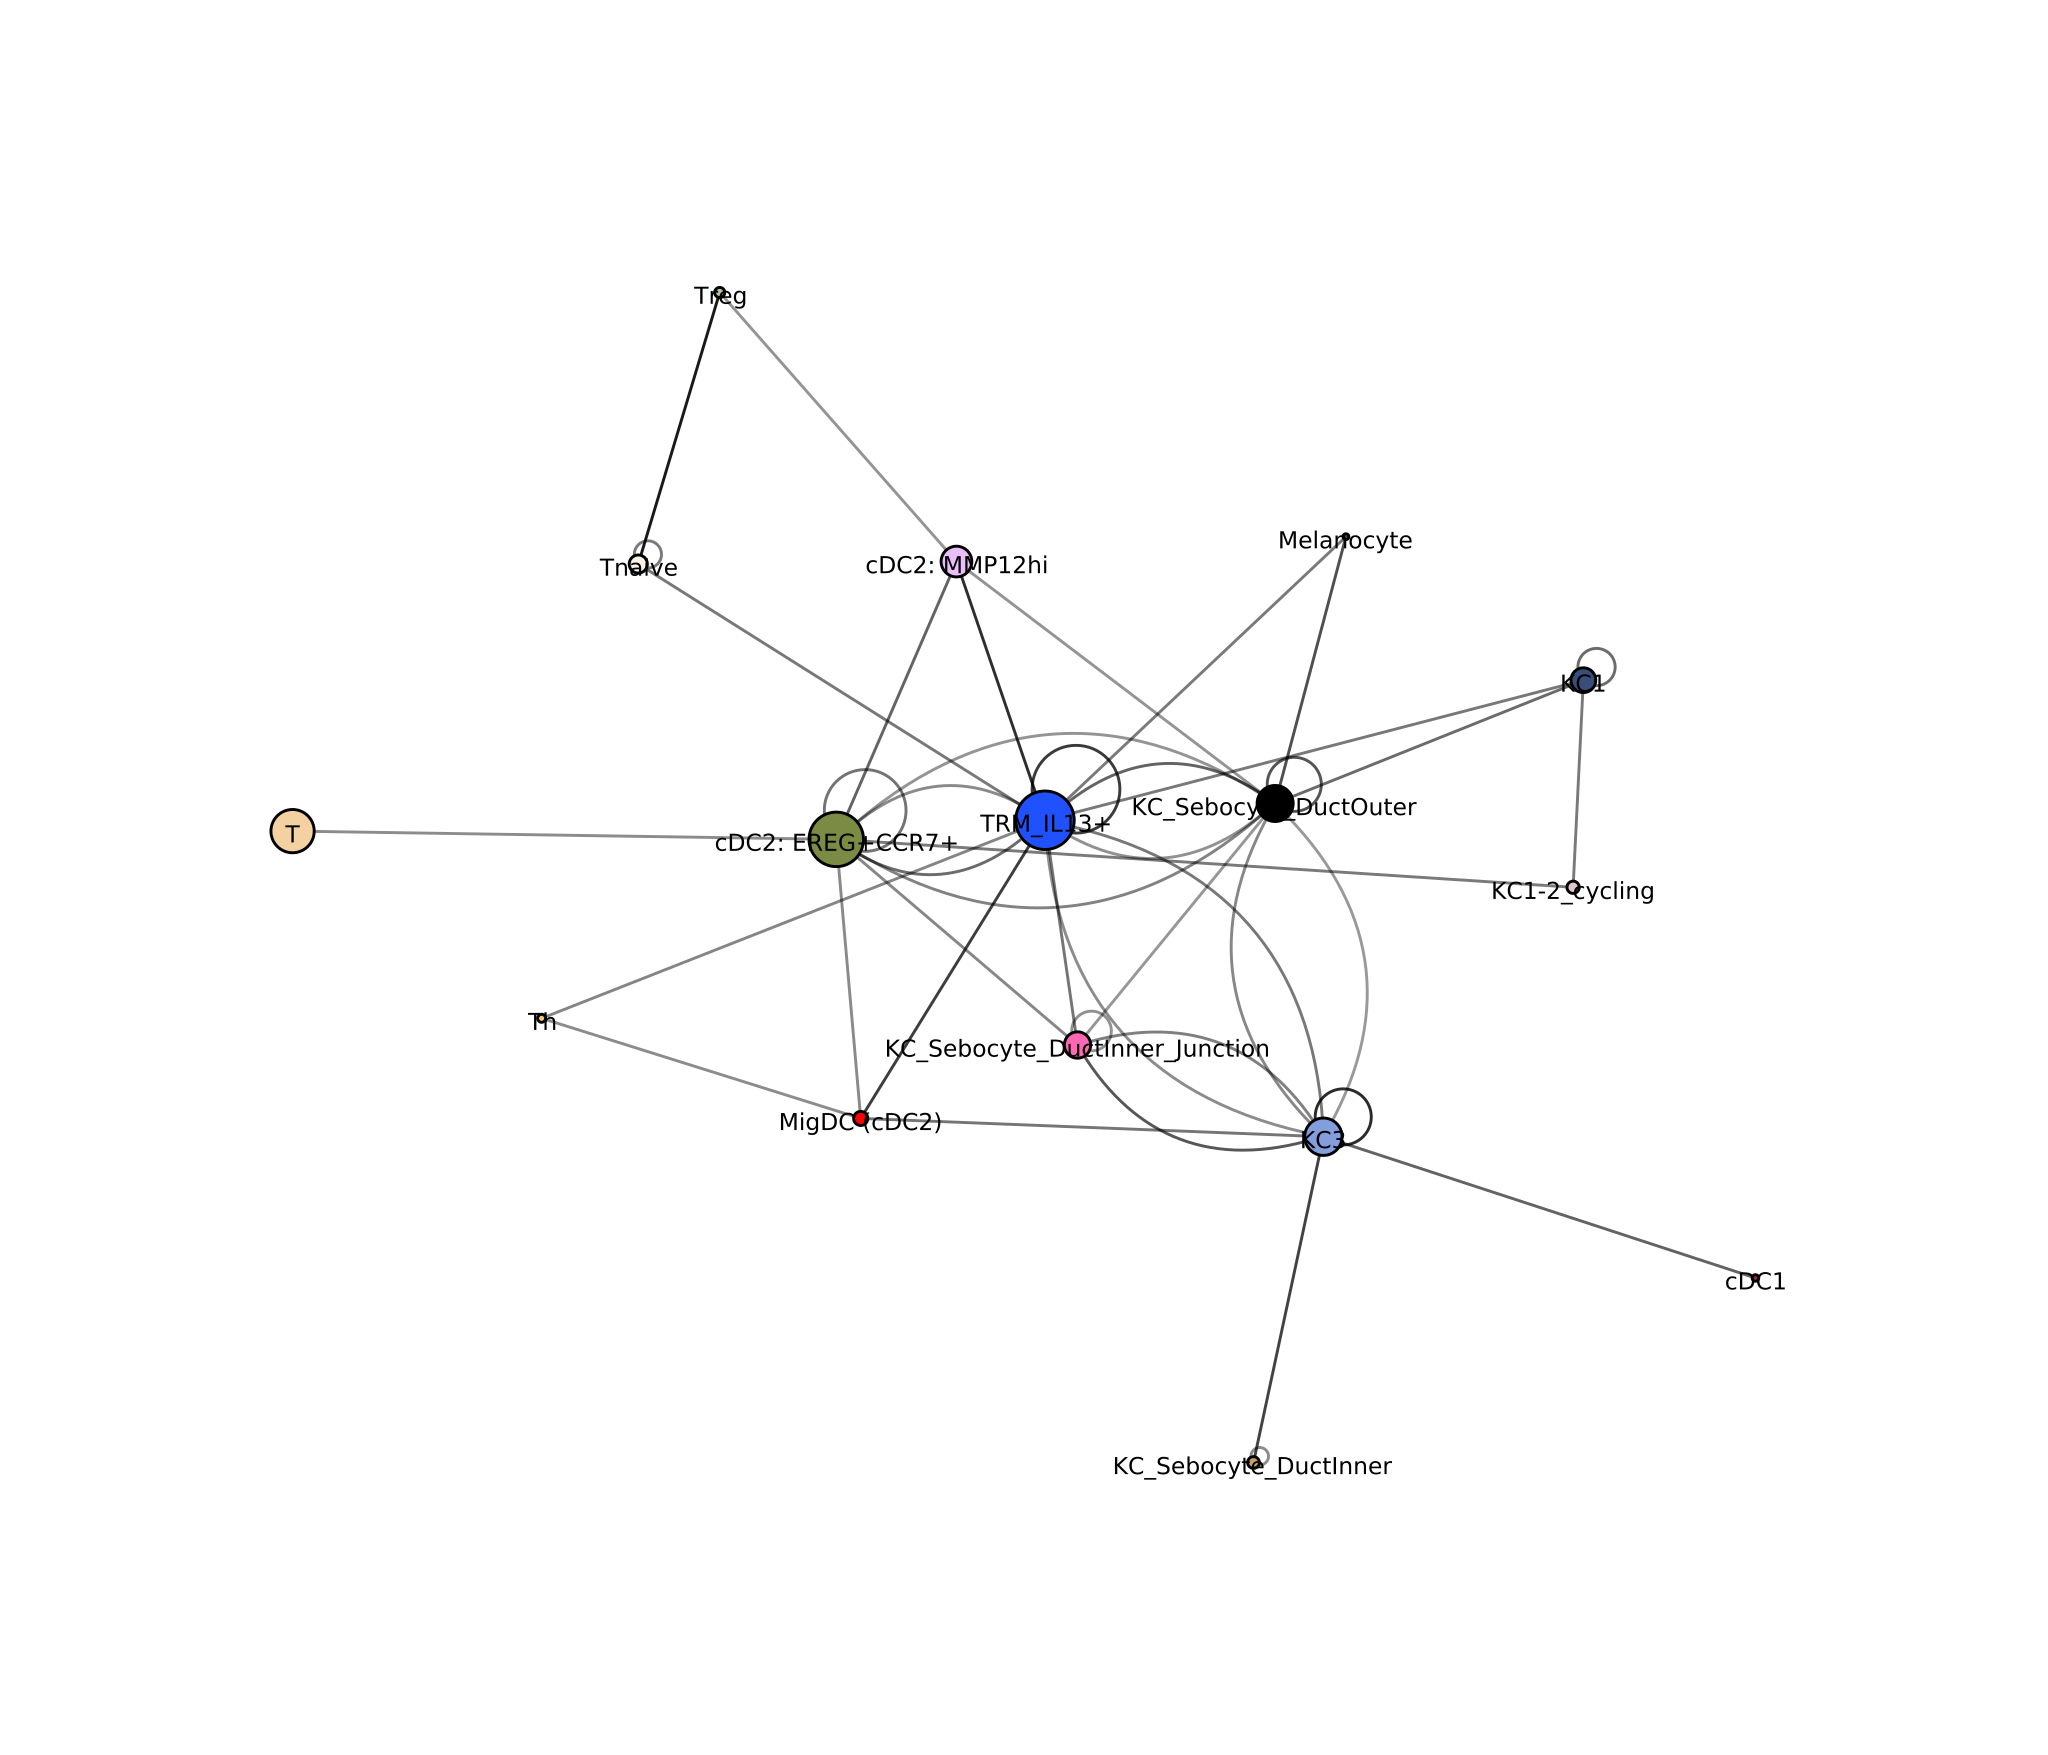

Psoriasis
(605, 4993)
(309, 4993)


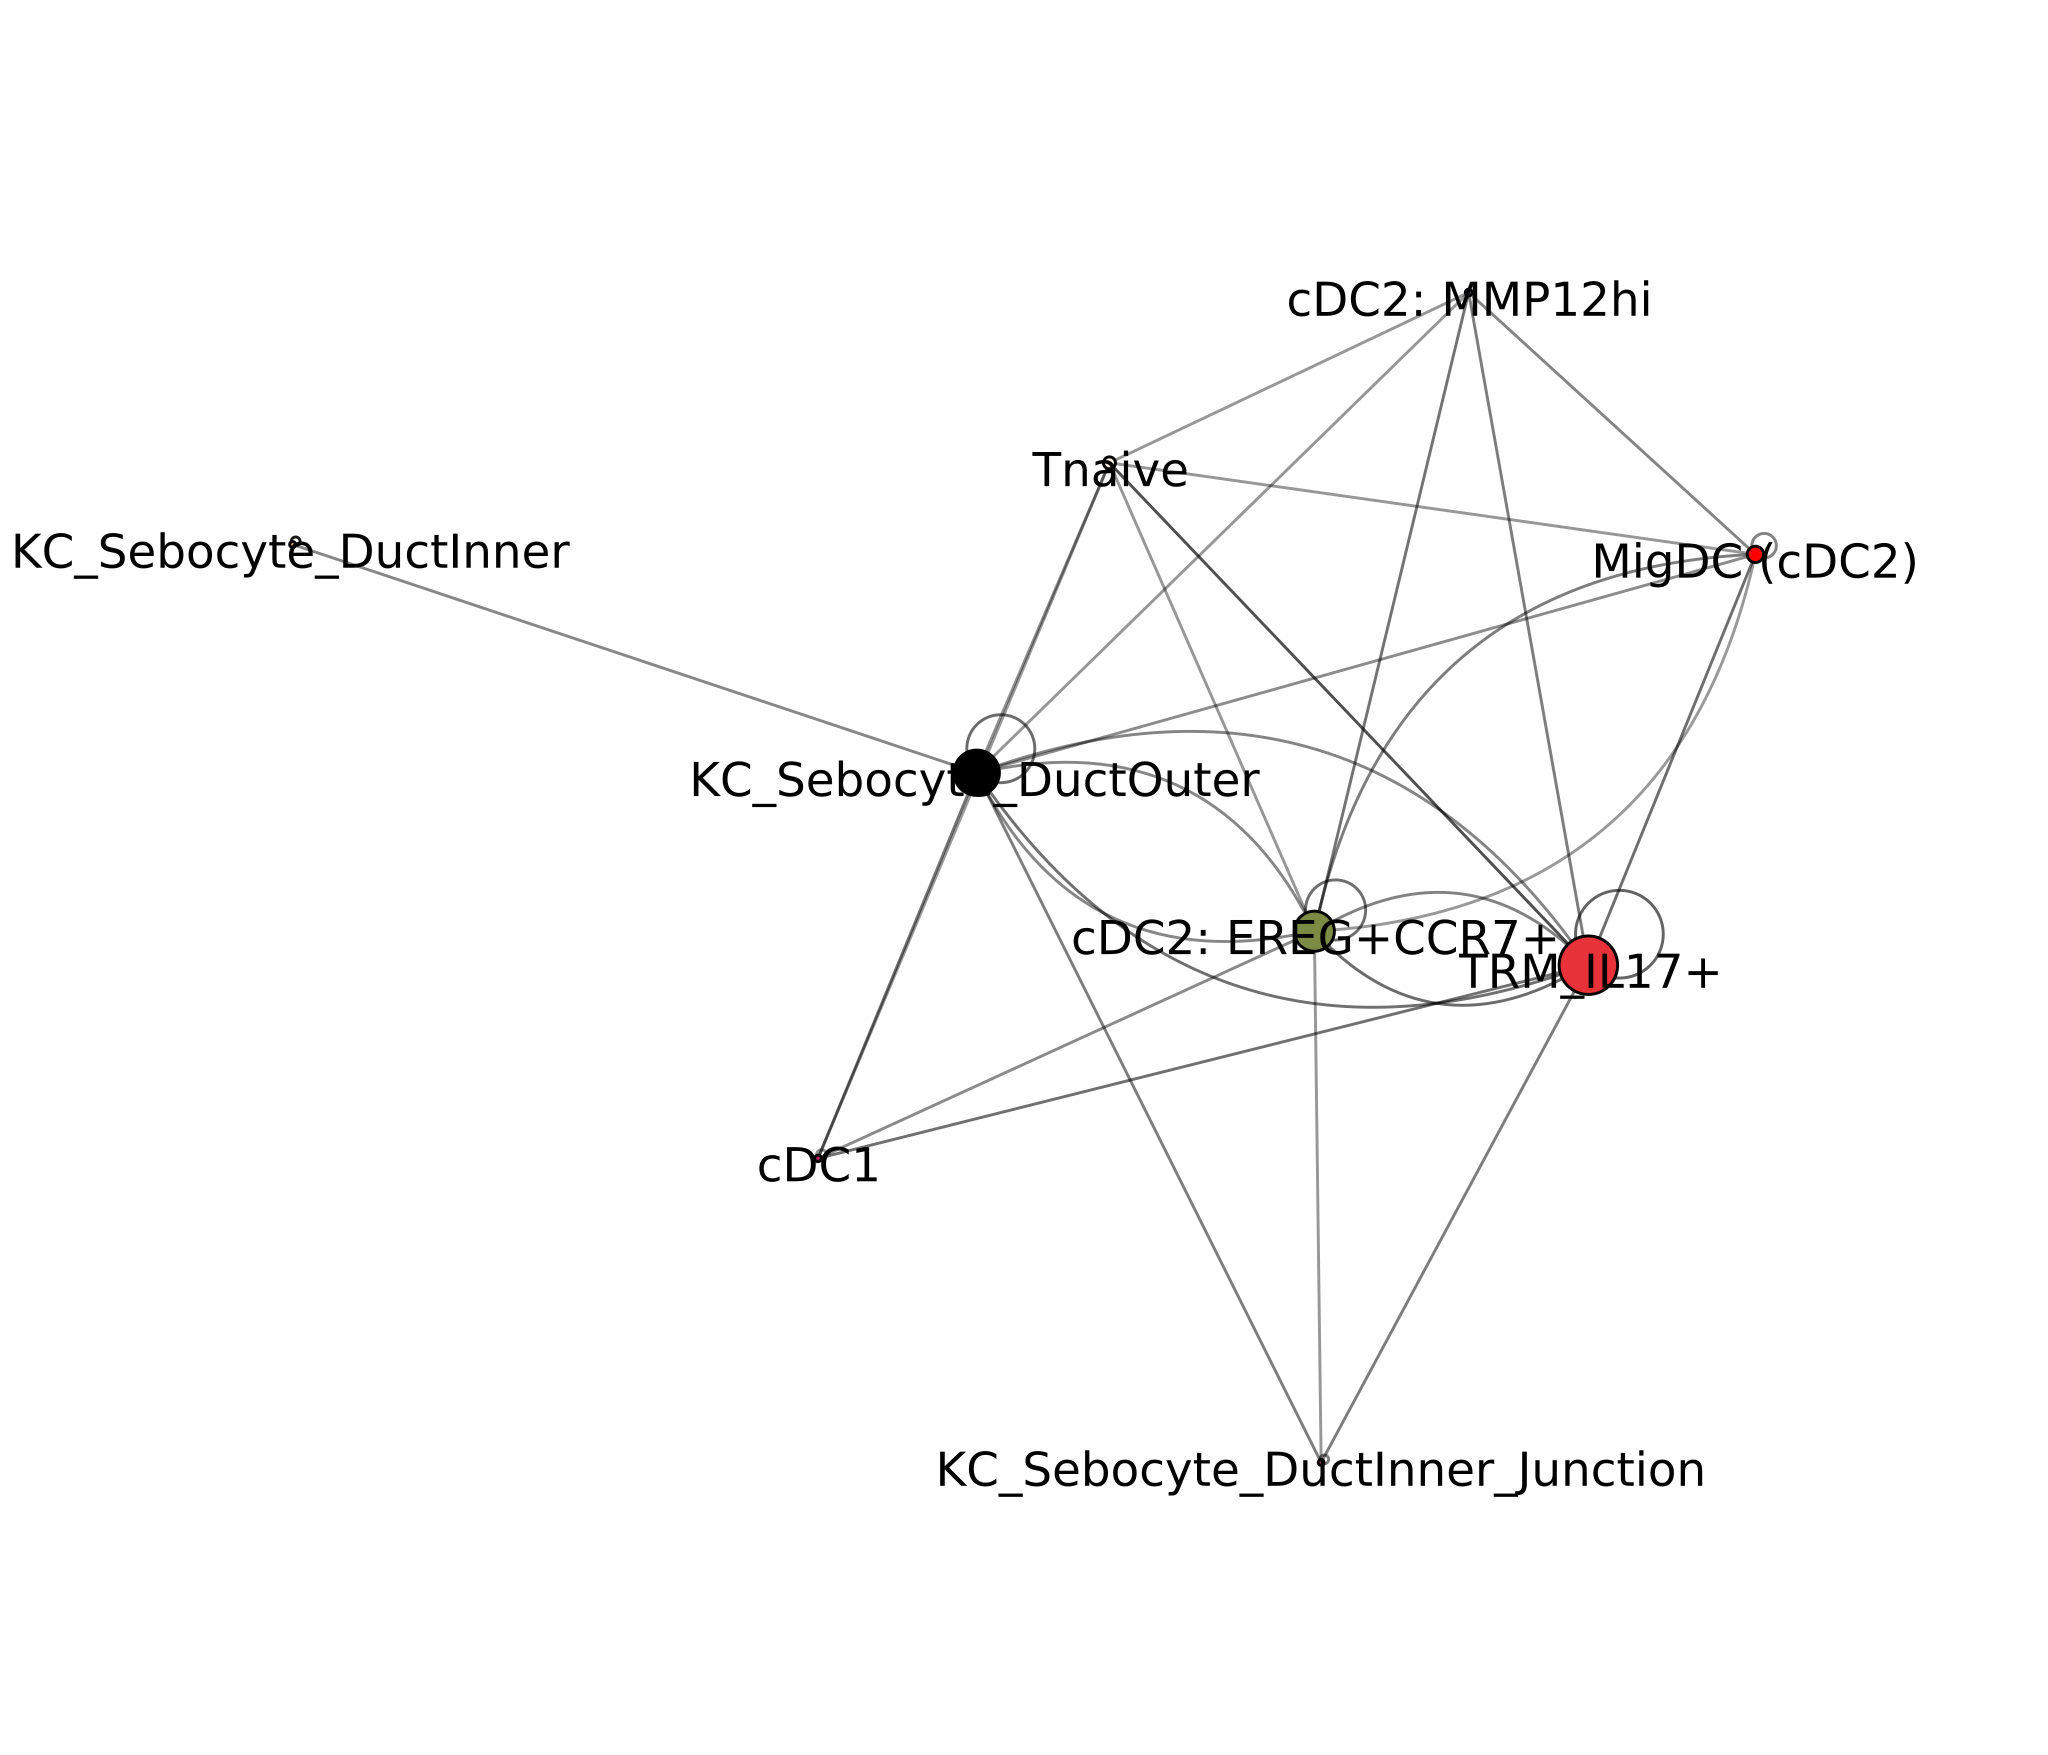

In [23]:
## layout="kk"

CELL_TYPE_LEVEL = "lvl5_annotation"
NICHE_LEVEL =  "niche19"
adata_5k.obs["niche_name"]=adata_5k.obs[NICHE_LEVEL]


RADIUS        = 10 # for sq.gr.spatial_neighbors
THRESHOLD     = 0.1
LAYOUT_METHOD = "kk"        # igraph layout
random.seed(42)
FILTER="count"  # percentage = 0.5% , "count" == 10 cells
CELL_COUNT=20

for DISEASE in ["AD", "Psoriasis"]:
    if DISEASE== "Psoriasis":
        CELL_COUNT=10
        FONT=80
    else:
        CELL_COUNT=20 # as more cells in AD
        FONT=40
    print(DISEASE)
    adata_5k_ii = adata_5k_i[adata_5k_i.obs["disease_overall"]==DISEASE]
    print(adata_5k_ii.shape)
    adata_5k_ii= adata_5k_ii[adata_5k_ii.obs["Site_status"].str.startswith("Lesional")]
    print(adata_5k_ii.shape)

#     if DISEASE== 'AD':
#         valid_ids = [x for x in adata_5k_ii.obs["info_id6"].unique() if "Relaps" not in x]
#         adata_5k_ii=adata_5k_ii[adata_5k_ii.obs["info_id6"].isin(valid_ids)]


    #adata_5k_ii=adata_5k_ii[adata_5k_ii.obs["disease_overall"]=="AD"]
    
    #print(adata_5k_ii.obs["info_id2"].value_counts())
    g = calc_graph(
    adata_5k_ii,
    batch_key="info_id2",
    cluster_key="veryfine_celltypes",
        FILTER="count",  # percentage = 0.5% , "count" == 10 cells
        min_cells_per_ct=CELL_COUNT,
        THRESHOLD=THRESHOLD
        
)
    display(plot_g(adata_5k_ii, g, (3500, 3000),
                FONT, # FONT
                   EDGE_SIZE=5,
                  NODE_WIDTH=5
                  )

                  )
    fig.save(f"{DISEASE}_sebiimmune_lesional_connectosome.pdf")